In [4]:
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from langchain_openai import ChatOpenAI
from langchain.tools import tool
from langgraph.graph import StateGraph
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
#define tool
@tool
def cancel_order(order_id:str) -> str:
    """ 
    Cancel an order that hasn't been shipped
    """
    return f"Order {order_id} has been successfully cancelled"

In [10]:
#create an agent
def call_model(state):
    msgs = state["messages"]
    order = state.get("order", {"order_id": "UNKNOWN"})

    llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0)
    llm_with_tools = llm.bind_tools([cancel_order])

    prompt = f"""
    You are an ecommerce support agent. ORDER_ID: {order['order_id']}
    If the customer asks to cancel, call cancel_order and then confirm.
    Otherwise, respond normally.
    """

    full_history = [SystemMessage(content=prompt)] + msgs

    response = llm_with_tools.invoke(full_history)
    output_messages = [response]

    #if gpt wants to do the function call
    if response.tool_calls:
        for tool_call in response.tool_calls:
            result = cancel_order.invoke(tool_call["args"])
            output_messages.append(
                ToolMessage(
                    content=[{"type": "text", "text": str(result)}],
                    tool_call_id=tool_call["id"]
                )
            )

        #2nd pass to the LLM
        final_response = llm_with_tools.invoke(full_history + output_messages)
        output_messages.append(final_response)

    return {"messages": output_messages}

In [11]:
#graph
def construct_graph():
    g = StateGraph(dict)
    g.add_node("assistant_agent", call_model)
    g.set_entry_point("assistant_agent")
    return g.compile()

graph = construct_graph()

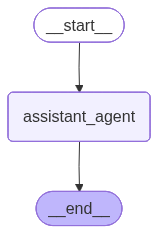

In [12]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
example_order = {"order_id":"A12345"}
convo = [HumanMessage(content="Please cancel my order.")]

result = graph.invoke({"order":example_order, "messages":convo})

for msg in result["messages"]:
    role = msg.__class__.__name__
    print(f"[{role}]: {msg.content if msg.content else "Calling Tool ..."}")

[AIMessage]: Calling Tool ...
[ToolMessage]: [{'type': 'text', 'text': 'Order A12345 has been successfully cancelled'}]
[AIMessage]: Order A12345 has been successfully cancelled.
